# GSGP-NN: Test Suite Execution & Regression Demo

This notebook provides a complete environment to:
1. **Execute all the unit & integration tests** in the project using `pytest`.
2. **Train a Geometric Semantic Genetic Programming Neural Network (GSGP-NN)** on a scikit-learn regression dataset (the Diabetes dataset) and evaluate its performance.

## 1. Execute Project Tests

In [1]:
import sys
import os
import pytest

# Ensure project root is in python path so that 'src' can be imported
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Running pytest on the 'tests' directory...")
exit_code = pytest.main(["-v", "../tests"])
print(f"Pytest finished with exit code: {exit_code} (0 means all tests passed)")

Running pytest on the 'tests' directory...
============================= test session starts ==============================
platform linux -- Python 3.10.20, pytest-9.1.1, pluggy-1.6.0 -- /home/gallobota/miniconda3/envs/gsgp_nn/bin/python
cachedir: .pytest_cache
rootdir: /home/gallobota/GSGP_NN
plugins: anyio-4.12.1
collecting ... collected 84 items

../tests/test_dataset.py::TestRegressionDataset::test_load_nonexistent_raises PASSED [  1%]
../tests/test_dataset.py::TestRegressionDataset::test_train_test_split_sizes PASSED [  2%]
../tests/test_dataset.py::TestRegressionDataset::test_num_features PASSED [  3%]
../tests/test_dataset.py::TestRegressionDataset::test_num_train_patterns PASSED [  4%]
../tests/test_dataset.py::TestRegressionDataset::test_y_mean_stored PASSED [  5%]
../tests/test_dataset.py::TestRegressionDataset::test_y_std_stored PASSED [  7%]
../tests/test_dataset.py::TestRegressionDataset::test_get_tensors_shapes PASSED [  8%]
../tests/test_dataset.py::TestRegressionDatase

## 2. Regression Demo with Scikit-Learn Dataset

In [2]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from src.data.loader import prepare_semantic_data
from src.models.gsgp_nn import GSGPNN
from src.training.trainer import Trainer
from src.training.early_stopping import EarlyStopping
from src.utils.device import get_device
from src.utils.seed import set_seed

# Set seeds for reproducibility
set_seed(42)
# Determine execution device (CPU or GPU/CUDA)
device = get_device()
print(f"Using device: {device}")

[Device] Using GPU: NVIDIA GeForce GTX 1650
[Device] VRAM: 4.3 GB
[Device] CUDA Capability: 7.5
Using device: cuda


### Load and Prepare Data
We load the scikit-learn Diabetes dataset (a classic regression task), scale the features and target to aid neural network optimization, and split into train/test sets.

In [3]:
X, y = load_diabetes(return_X_y=True)
print(f"Dataset features shape: {X.shape}")
print(f"Dataset target shape: {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize targets
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert targets to PyTorch tensors on target device
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

Dataset features shape: (442, 10)
Dataset target shape: (442,)


### GP Populations & Semantics Preparation
We use the helper function `prepare_semantic_data` to generate GP populations and compute the initial, parent, and route semantics for both training and testing.

In [4]:
num_nodes = 10
num_layers = 3
pop_size = 40

# Prepare training semantic data
print("Generating GP trees and evaluating train semantics...")
train_data = prepare_semantic_data(
    X=X_train_scaled,
    num_nodes=num_nodes,
    num_layers=num_layers,
    population_size=pop_size,
    device=device
)

# Evaluate the same GP trees on the test dataset to get test semantics
print("Evaluating test semantics...")
test_data = prepare_semantic_data(
    X=X_test_scaled,
    num_nodes=num_nodes,
    num_layers=num_layers,
    population_size=pop_size,
    device=device,
    initial_population=train_data["initial_population"],
    auxiliary_population=train_data["auxiliary_population"],
    evaluator=train_data["evaluator"],
)
print("Train and test semantic data successfully prepared!")

Generating GP trees and evaluating train semantics...
[GP] Generating populations of size 40...
[GP] Evaluating initial population semantics...
[GP] Evaluating auxiliary population semantics...
[GP] Semantic tensors ready — initial: torch.Size([10, 353]), parent: torch.Size([10, 353]), routes: 3 layers × (N=10, M=353)
Evaluating test semantics...
[GP] Using provided populations (skipping generation)...
[GP] Evaluating initial population semantics...
[GP] Evaluating auxiliary population semantics...
[GP] Semantic tensors ready — initial: torch.Size([10, 89]), parent: torch.Size([10, 89]), routes: 3 layers × (N=10, M=89)
Train and test semantic data successfully prepared!


### Initialize and Train the GSGP-NN Model

In [5]:
# Define model
model = GSGPNN(num_nodes=num_nodes, num_layers=num_layers).to(device)
print(model.summary())

# Define early stopping
early_stopping = EarlyStopping(patience=20, min_delta=1e-5, warmup_epochs=10)

# Train model using Trainer
trainer = Trainer(
    model=model,
    learning_rate=0.01,
    early_stopping=early_stopping
)

history = trainer.fit(
    semantic_data=train_data,
    y_train=y_train_tensor,
    epochs=200
)

GSGPNN(N=10, K=3)
  Trainable parameters: 401
  Layers:
    [0] GSGPNNLayer — alpha: (11, 10), ms: (10,), beta: (10,)
    [1] GSGPNNLayer — alpha: (11, 10), ms: (10,), beta: (10,)
    [2] GSGPNNLayer — alpha: (11, 10), ms: (10,), beta: (10,)
    [out] Linear — weight: (1, 10), bias: (1,)
Epoch    1: Loss = 0.965656   [1783027435.742s]
Epoch    2: Loss = 0.943062   [1783027435.758s]
Epoch    3: Loss = 0.920643   [1783027435.771s]
Epoch    4: Loss = 0.898162   [1783027435.798s]
Epoch    5: Loss = 0.875099   [1783027435.810s]
Epoch    6: Loss = 0.851445   [1783027435.821s]
Epoch    7: Loss = 0.827543   [1783027435.850s]
Epoch    8: Loss = 0.803593   [1783027435.862s]
Epoch    9: Loss = 0.780201   [1783027435.874s]
Epoch   10: Loss = 0.757907   [1783027435.885s]
Epoch   11: Loss = 0.737377   [1783027435.899s]
Epoch   12: Loss = 0.719194   [1783027435.910s]
Epoch   13: Loss = 0.703617   [1783027435.921s]
Epoch   14: Loss = 0.690646   [1783027435.933s]
Epoch   15: Loss = 0.679669   [17830274

### Model Evaluation
Let's visualize the loss history, calculate metrics (MSE, R²) on the test set, and plot actual vs predicted values.

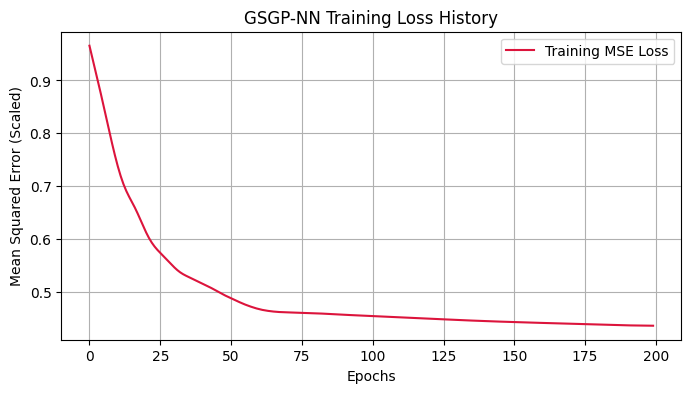

Test Mean Squared Error (MSE): 3337.5830
Test R2 Score: 0.3700


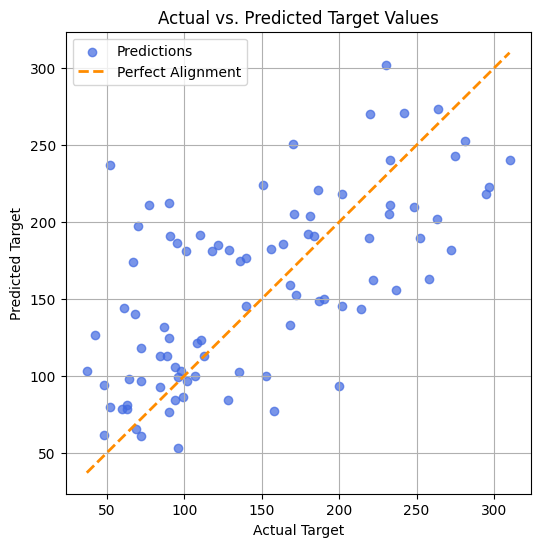

In [6]:
# Plot Loss curve
plt.figure(figsize=(8, 4))
plt.plot(history["loss_history"], label="Training MSE Loss", color="crimson")
plt.title("GSGP-NN Training Loss History")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Scaled)")
plt.legend()
plt.grid(True)
plt.show()

# Run inference on test data
y_pred_scaled = trainer.predict(test_data).cpu().numpy()

# Inverse scale targets/predictions back to original space
y_test_original = y_test
y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Compute metrics
mse = mean_squared_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)
print(f"Test Mean Squared Error (MSE): {mse:.4f}")
print(f"Test R2 Score: {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test_original, y_pred_original, color="royalblue", alpha=0.7, label="Predictions")
plt.plot([min(y_test_original), max(y_test_original)], [min(y_test_original), max(y_test_original)], 
         color="darkorange", linestyle="--", linewidth=2, label="Perfect Alignment")
plt.title("Actual vs. Predicted Target Values")
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.legend()
plt.grid(True)
plt.show()

## 3. Comparison with a Standard Neural Network (MLP)

We train a simple feed-forward network (Multi-Layer Perceptron) with a comparable number of parameters on the **same data** (raw features, not GP semantics) to benchmark the GSGP-NN against a standard baseline.

In [7]:
import torch.nn as nn

class SimpleNN(nn.Module):
    """Standard MLP baseline with comparable capacity to GSGP-NN (N=10, K=3 -> 401 params).
    
    Architecture: 10 -> 20 -> 10 -> 1  (441 params, ~10% more than GSGP-NN)
    """
    def __init__(self, input_dim: int = 10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 20),
            nn.ReLU(),
            nn.Linear(20, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1)
    
    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Instantiate and show parameter count
baseline_model = SimpleNN(input_dim=X_train_scaled.shape[1]).to(device)
print(f"SimpleNN parameters: {baseline_model.count_parameters():,}")
print(f"GSGP-NN parameters: {model.count_parameters():,}")
print(f"Ratio: {baseline_model.count_parameters() / model.count_parameters():.2f}x")

SimpleNN parameters: 441
GSGP-NN parameters: 401
Ratio: 1.10x


In [8]:
# Train SimpleNN on raw features (same train/test split, same hyperparameters)
from src.training.early_stopping import EarlyStopping

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)

optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.01)
early_stopping_baseline = EarlyStopping(patience=20, min_delta=1e-5, warmup_epochs=10)

baseline_loss_history = []
baseline_model.train()

for epoch in range(1, 201):
    optimizer.zero_grad()
    y_pred = baseline_model(X_train_tensor)
    loss = nn.functional.mse_loss(y_pred, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    loss_val = loss.item()
    baseline_loss_history.append(loss_val)
    
    if epoch <= 10 or epoch % 25 == 0:
        print(f"Epoch {epoch:3d}: Loss = {loss_val:.6f}")
    
    if early_stopping_baseline(loss_val):
        print(f"[EarlyStopping] Stopped at epoch {epoch}")
        break

print(f"\nSimpleNN training completed \u2014 final loss: {baseline_loss_history[-1]:.6f}")

Epoch   1: Loss = 0.974224
Epoch   2: Loss = 0.907101
Epoch   3: Loss = 0.846519
Epoch   4: Loss = 0.797744
Epoch   5: Loss = 0.765639
Epoch   6: Loss = 0.746712
Epoch   7: Loss = 0.731966
Epoch   8: Loss = 0.714780
Epoch   9: Loss = 0.696828
Epoch  10: Loss = 0.682027
Epoch  25: Loss = 0.506337
Epoch  50: Loss = 0.385854
Epoch  75: Loss = 0.309880
Epoch 100: Loss = 0.245680
Epoch 125: Loss = 0.203119
Epoch 150: Loss = 0.170836
Epoch 175: Loss = 0.144455
Epoch 200: Loss = 0.124224

SimpleNN training completed — final loss: 0.124224


MODEL COMPARISON ON TEST SET
Metric               GSGP-NN            SimpleNN          
-------------------- ------------------ ------------------
MSE                  3337.5830          5270.8233         
R²                   0.3700             0.0052            
Parameters           401                441               

✔ GSGP-NN outperforms SimpleNN by 0.3649 R²


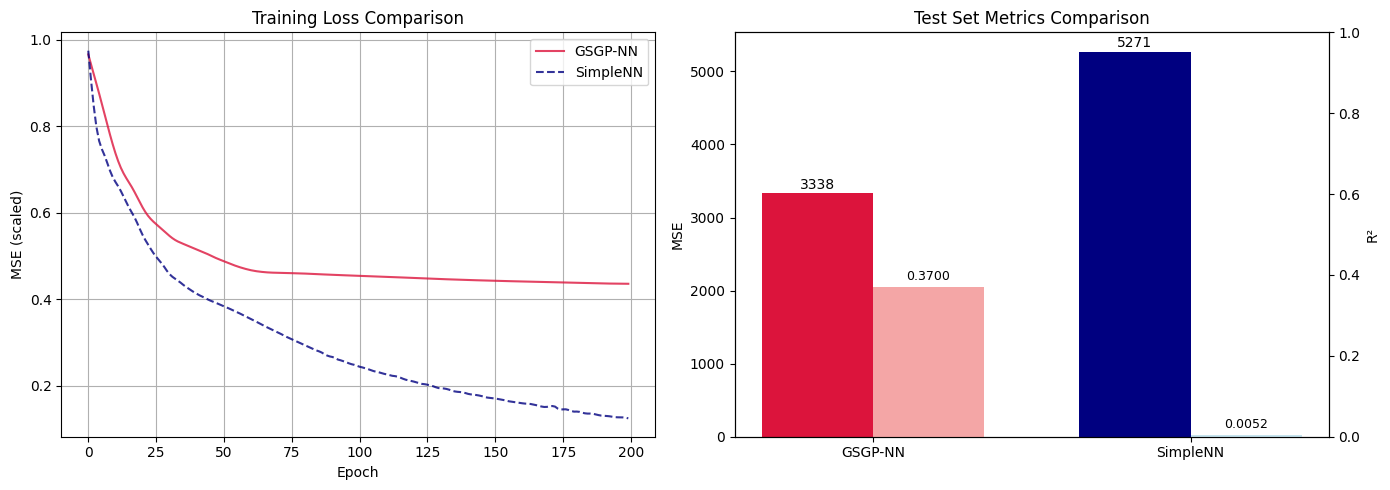

In [9]:
# Evaluate both models on test data
from sklearn.metrics import mean_squared_error, r2_score

baseline_model.eval()
with torch.no_grad():
    y_pred_baseline_scaled = baseline_model(X_test_tensor).cpu().numpy()

y_pred_baseline_orig = scaler_y.inverse_transform(y_pred_baseline_scaled.reshape(-1, 1)).flatten()

mse_baseline = mean_squared_error(y_test, y_pred_baseline_orig)
r2_baseline = r2_score(y_test, y_pred_baseline_orig)

print("=" * 60)
print("MODEL COMPARISON ON TEST SET")
print("=" * 60)
print(f"{'Metric':<20} {'GSGP-NN':<18} {'SimpleNN':<18}")
print(f"{'-'*20} {'-'*18} {'-'*18}")
print(f"{'MSE':<20} {mse:<18.4f} {mse_baseline:<18.4f}")
print(f"{'R²':<20} {r2:<18.4f} {r2_baseline:<18.4f}")
print(f"{'Parameters':<20} {model.count_parameters():<18,} {baseline_model.count_parameters():<18,}")

# Plot training loss comparison
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history["loss_history"], label="GSGP-NN", color="crimson", alpha=0.8)
plt.plot(baseline_loss_history, label="SimpleNN", color="navy", alpha=0.8, linestyle="--")
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE (scaled)")
plt.legend()
plt.grid(True)

# Plot bar chart of test metrics
plt.subplot(1, 2, 2)
x = np.arange(2)
width = 0.35
bars1 = plt.bar(x - width/2, [mse, mse_baseline], width, 
                label='MSE', color=['crimson', 'navy'])
plt.ylabel('MSE')
plt.xticks(x, ['GSGP-NN', 'SimpleNN'])
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=10)

ax2 = plt.gca().twinx()
bars2 = ax2.bar(x + width/2, [r2, r2_baseline], width, 
                label='R²', color=['lightcoral', 'lightblue'], alpha=0.7)
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.title("Test Set Metrics Comparison")
fig = plt.gcf()
plt.tight_layout()
# Summary
print()
if r2 >= r2_baseline:
    print(f"\u2714 GSGP-NN outperforms SimpleNN by {abs(r2 - r2_baseline):.4f} R²")
else:
    print(f"\u2716 SimpleNN outperforms GSGP-NN by {abs(r2 - r2_baseline):.4f} R²")

plt.show()

